# Conformal Prediction for Privacy-Preserving Machine Learning

Integrating conformal prediction with encrypted data learning could be
useful for privacy-preserving applications where uncertainty matter.

## Introduction

Using conformal prediction for encrypted data requires adapting the methodology to ensure compatibility with encryption techniques while maintaining the validity of predictions. Here's a general approach:

1. **Data Encryption**:
   - Encrypt sensitive data using cryptographic methods like homomorphic encryption, which allows computations on encrypted data without decryption.

2. **Nonconformity Measure**:
   - Define a nonconformity measure that works on encrypted features. This may involve designing algorithms compatible with encrypted data formats.

3. **Prediction Region Construction**:
   - Use conformal prediction algorithms to compute prediction regions based on encrypted nonconformity scores. Ensure that the scoring mechanism does not require access to plaintext data.

4. **Validation**:
   - Validate the conformal prediction intervals using encrypted calibration sets, ensuring exchangeability or other assumptions hold for encrypted datasets.


This approach ensures privacy while leveraging conformal prediction's uncertainty quantification capabilities.


In [1]:
#!pip install pycryptodome
#!pip install Pillow

In [2]:
from Crypto.Cipher import AES
import io
import PIL.Image
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import random
import string

In [3]:
print("PyTorch version:", torch.__version__)

torch.manual_seed(2024)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(2024)

PyTorch version: 2.10.0+cu130


In [4]:
chars = ''.join([str(i) for i in range(10)]) + string.ascii_lowercase
def random_string_generator(allowed_chars = chars, str_size = 16):
    return ''.join(random.choice(allowed_chars) for x in range(str_size))

In [5]:
# AES algorithm requires two different parameters for encryption,
# a key and an initialization vector (IV).
# https://en.wikipedia.org/wiki/Advanced_Encryption_Standard
# NOTE: must match the (key, IV) stated in the paper and used by
# ablation_keys.py / intersection_claude.py.

key = b'abs2kas126oZbdXs'
iv = b'1nsdjah72MdnJ12a'

## Load a dataset: MNIST

Load and prepare the [MNIST dataset](http://yann.lecun.com/exdb/mnist/). The pixel values of the images range from 0 through 255.

At this stage we are not dividing the values by `255.0`. We will be doing encryption of original raw data.

In [6]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

x_train = mnist_train.data.numpy()
y_train = mnist_train.targets.numpy()
x_test = mnist_test.data.numpy()
y_test = mnist_test.targets.numpy()

Let us view some examples:

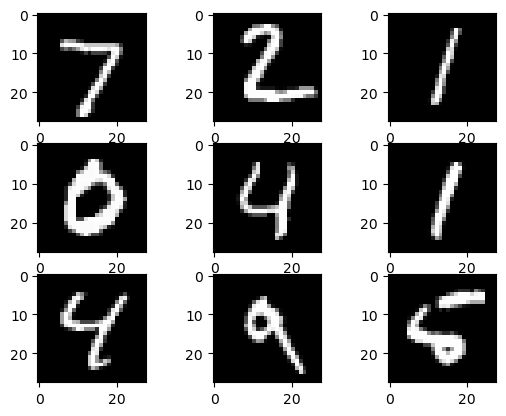

In [7]:
from matplotlib import pyplot
for i in range(9):
  pyplot.subplot(330 + 1 + i)
  pyplot.imshow(x_test[i], cmap=pyplot.get_cmap('gray'))
pyplot.show()

## Data Encryption with AES

https://en.wikipedia.org/wiki/Advanced_Encryption_Standard

In [8]:
# AES in CBC mode, as described in the paper (28*28 = 784 bytes = 49 AES
# blocks, so no padding is needed).
cbc_cipher = AES.new(key, AES.MODE_CBC, iv)

Let us see what this encryption is doing to an image:

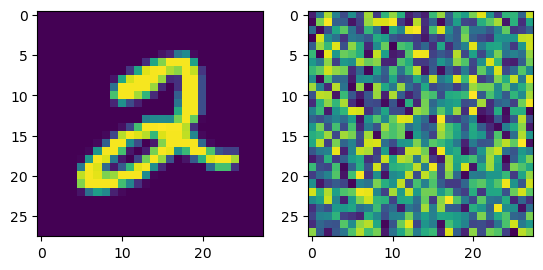

In [9]:
im1 = x_train[5,:,:]  # some image from MNIST
enc_data = cbc_cipher.encrypt(im1.tobytes())
im1enc = np.array(list(enc_data)).reshape((28,28))

plt.subplot(121)
plt.imshow(im1)
plt.subplot(122)
plt.imshow(im1enc)

In [10]:
def encrypt_data(data, key = None, iv = None):
  '''
  IN:
    data - np.array where first dimension is nr of examples, then image size
    key - 16-byte key; if None, a FRESH random key is drawn for every image
    iv - 16-byte IV; if None, a FRESH random IV is drawn for every image
  OUT:
    encrypted data (same dim as data)
  '''
  encrdata = np.zeros(data.shape)
  for i in range(data.shape[0]):
    im_ = data[i,:,:]
    # Per-image randomness must be drawn INSIDE the loop; assigning to the
    # `key`/`iv` arguments themselves would silently reuse the first draw
    # for all subsequent images.
    key_i = key if key is not None else bytes(random_string_generator(),'utf-8')
    iv_i = iv if iv is not None else bytes(random_string_generator(),'utf-8')
    cipher = AES.new(key_i, AES.MODE_CBC, iv_i)
    encdat = cipher.encrypt(im_.tobytes())
    imenc = np.array(list(encdat)).reshape((28,28))
    encrdata[i, :, :] = imenc
  return encrdata

Now we enctypte MNIST with a fixed password, and with random passwords for each image.

In [11]:
encr_train = encrypt_data(x_train, key, iv)
encr_test = encrypt_data(x_test, key, iv)

In [12]:
encr_train2 = encrypt_data(x_train)
encr_test2 = encrypt_data(x_test)



---



## Data Visualisation with T-SNE

In [13]:
from sklearn.manifold import TSNE

**Reshape the data**:

T-SNE works with 2D data. Since MNIST images are 28x28, we need to flatten them into a 1D vector.

In [14]:
x_train_tsne = x_train.reshape(x_train.shape[0], -1)

**Apply T-SNE**:

Create a T-SNE object and fit it to your data. This step might take some time, depending on the size of the dataset and the chosen parameters.

In [15]:
tsne = TSNE(n_components=2, random_state=42)
x_tsne = tsne.fit_transform(x_train_tsne[:10000]) # Using a subset for faster processing

**Visualize the results**:

Plot the transformed data points, using different colors to represent different digit classes.

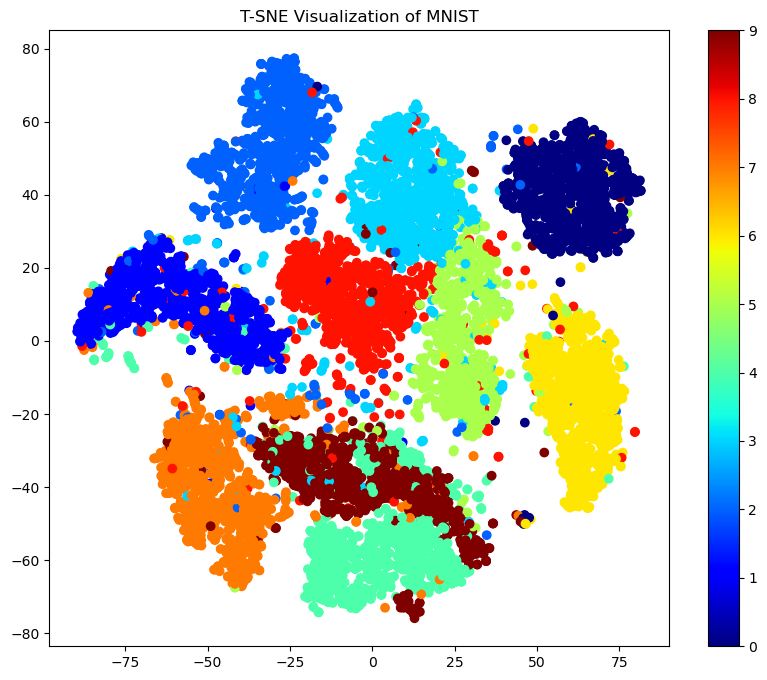

In [16]:
plt.figure(figsize=(10, 8))
plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=y_train[:10000], cmap='jet')
plt.colorbar()
plt.title('T-SNE Visualization of MNIST')
plt.show()

Let us do the similar visualisation for encrypted data (encr_train):

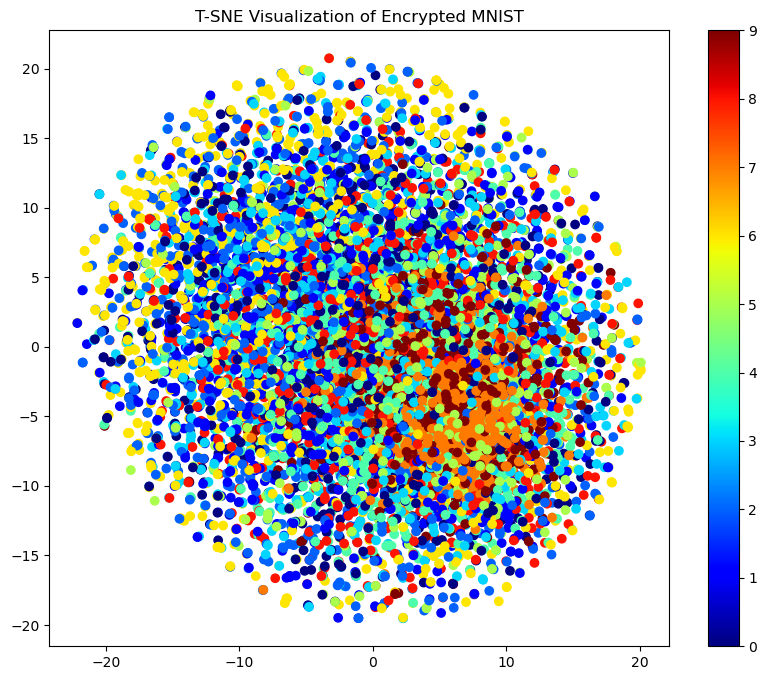

In [17]:
encr_train_tsne = encr_train.reshape(x_train.shape[0], -1)
tsne = TSNE(n_components=2, random_state=42)
encr_tsne = tsne.fit_transform(encr_train_tsne[:10000])

plt.figure(figsize=(10, 8))
plt.scatter(encr_tsne[:, 0], encr_tsne[:, 1], c=y_train[:10000], cmap='jet')
plt.colorbar()
plt.title('T-SNE Visualization of Encrypted MNIST')
plt.show()

And for random encryption with random passwords:

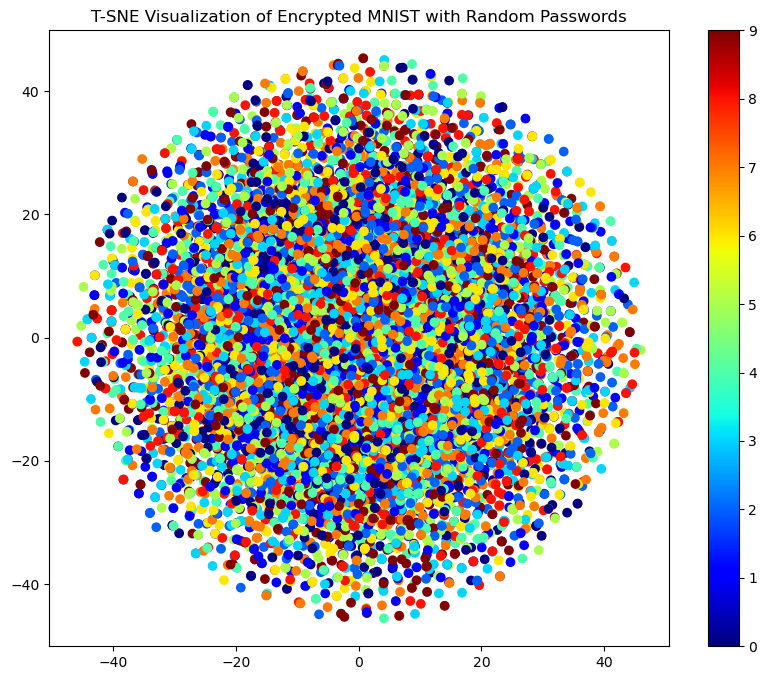

In [18]:
encr_train2_tsne = encr_train2.reshape(x_train.shape[0], -1)
tsne = TSNE(n_components=2, random_state=42)
encr2_tsne = tsne.fit_transform(encr_train2_tsne[:10000])

plt.figure(figsize=(10, 8))
plt.scatter(encr2_tsne[:, 0], encr2_tsne[:, 1], c=y_train[:10000], cmap='jet')
plt.colorbar()
plt.title('T-SNE Visualization of Encrypted MNIST with Random Passwords')
plt.show()



---



## Build a deep learning machine learning model

Encryption does not preserve temporal or spacial structure, so using
CNN will not be "natural".
Let us start with simple multilayer network.

Build a simple PyTorch model:

In [19]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleMLP(nn.Module):
  def __init__(self, image_height, image_width, num_classes=10):
    super().__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(image_height * image_width, 128)
    self.dropout = nn.Dropout(0.2)
    self.fc2 = nn.Linear(128, num_classes)

  def forward(self, x):
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = self.dropout(x)
    return self.fc2(x)


def _to_tensor_images(x):
  x_t = torch.as_tensor(x, dtype=torch.float32)
  if x_t.ndim == 3:
    x_t = x_t.unsqueeze(1)
  if x_t.max() > 1:
    x_t = x_t / 255.0
  return x_t


def _to_tensor_labels(y):
  return torch.as_tensor(y, dtype=torch.long)


def build_model(image_height, image_width, num_classes = 10):
  return SimpleMLP(image_height, image_width, num_classes).to(DEVICE)


def train_model(model, x_train, y_train, epochs=32, batch_size=64, lr=1e-3):
  x_t = _to_tensor_images(x_train)
  y_t = _to_tensor_labels(y_train)
  loader = DataLoader(
      TensorDataset(x_t, y_t),
      batch_size=batch_size,
      shuffle=True,
      generator=torch.Generator().manual_seed(2024)
  )

  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  model.train()
  for _ in range(epochs):
    for xb, yb in loader:
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)
      optimizer.zero_grad()
      logits = model(xb)
      loss = criterion(logits, yb)
      loss.backward()
      optimizer.step()

  return model


def evaluate_model(model, x, y):
  x_t = _to_tensor_images(x).to(DEVICE)
  y_t = _to_tensor_labels(y).to(DEVICE)

  criterion = nn.CrossEntropyLoss()
  model.eval()
  with torch.no_grad():
    logits = model(x_t)
    loss = criterion(logits, y_t).item()
    acc = (logits.argmax(dim=1) == y_t).float().mean().item()

  print(f"loss: {loss:.4f} - accuracy: {acc:.4f}")
  return (loss, acc)


def predict_proba(model, x):
  x_t = _to_tensor_images(x).to(DEVICE)
  model.eval()
  with torch.no_grad():
    probs = torch.softmax(model(x_t), dim=1)
  return probs.cpu().numpy()

In [20]:
model1 = build_model(28, 28)
train_model(model1, x_train, y_train, epochs=32, batch_size=64)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

The `Model.evaluate` method checks the model's performance, usually on a [validation set](https://developers.google.com/machine-learning/glossary#validation-set) or [test set](https://developers.google.com/machine-learning/glossary#test-set).

In [21]:
evaluate_model(model1, x_test, y_test)

loss: 0.0828 - accuracy: 0.9795


(0.08282226324081421, 0.9794999957084656)

For encrypted data:

In [22]:
model_encr = build_model(28, 28)
train_model(model_encr, encr_train, y_train, epochs=32, batch_size=64)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [23]:
evaluate_model(model_encr, encr_test, y_test)

loss: 1.7798 - accuracy: 0.3358


(1.7797523736953735, 0.3357999920845032)

In [24]:
model_encr2 = build_model(28, 28)
train_model(model_encr2, encr_train2, y_train, epochs=32, batch_size=64)

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [25]:
evaluate_model(model_encr2, encr_test2, y_test)

loss: 2.3011 - accuracy: 0.1135


(2.301072359085083, 0.11349999904632568)

**Summary of test evaluations:**

In [26]:
print('Model on regular MNIST:')
score = evaluate_model(model1, x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

print("\n \n ")

print('Model on encrypted MNIST:')
score = evaluate_model(model_encr, encr_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

print("\n \n ")

print('Model on encrypted MNIST (with randomised keys/iv):')
score = evaluate_model(model_encr2, encr_test2, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Model on regular MNIST:
loss: 0.0828 - accuracy: 0.9795
Test loss: 0.08282226324081421
Test accuracy: 0.9794999957084656

 
 
Model on encrypted MNIST:
loss: 1.7798 - accuracy: 0.3358
Test loss: 1.7797523736953735
Test accuracy: 0.3357999920845032

 
 
Model on encrypted MNIST (with randomised keys/iv):
loss: 2.3011 - accuracy: 0.1135
Test loss: 2.301072359085083
Test accuracy: 0.11349999904632568


-------------------

<br>

## Analysis of Encrypted MNIST

If you want your model to return probabilities, use softmax on logits:

```python
probs = predict_proba(model, x_test)
predictions_on_tests = np.argmax(probs, axis=1)
```

In [27]:
def probability_model(model):
  def _predict(x):
    return predict_proba(model, x)
  return _predict

In [28]:
encr_probability_model = probability_model(model_encr)

<br><br>

### Encrypted MNIST and Inductive CP with simple loss function
--------------

So, we trained our model on the encrypted training data, and now let us forget about this training data.

We devide encrypted test data into two parts: `encr_calibrate_cp` and `encr_test_cp`,
 with corresponding labels `y_calibrate_cp` and `y_test_cp`

In [29]:
from sklearn.model_selection import train_test_split

encr_calibrate_cp, encr_test_cp, y_calibrate_cp , y_test_cp = train_test_split(encr_test, y_test,
                                                    test_size=0.5,
                                                    random_state=0,
                                                    shuffle=True,
                                                    stratify=y_test)

encr_calibrate_cp = encr_calibrate_cp.astype("float32") / 255
encr_test_cp = encr_test_cp.astype("float32") / 255

Let us look into performance of our model on `encr_calibrate_cp, encr_test_cp`:

In [30]:
evaluate_model(model_encr, encr_test_cp, y_test_cp)

loss: 1.7901 - accuracy: 0.3314


(1.79007887840271, 0.33139997720718384)

In [31]:
evaluate_model(model_encr, encr_calibrate_cp, y_calibrate_cp)

loss: 1.7694 - accuracy: 0.3402


(1.7694257497787476, 0.3401999771595001)

<br>
The non-conformity scores for `encr_calibrate_cp` can be calculated in advance by using the loss function:
<br>

In [32]:
# alpha scores for calibrating set

probs_calibrate = np.clip(encr_probability_model(encr_calibrate_cp), 1e-12, 1.0)
A_calibrate = -np.log(probs_calibrate)
alpha_calibrate = np.array([A_calibrate[i, y_calibrate_cp[i]] for i in range(len(y_calibrate_cp))])

In [ ]:
fig = plt.figure(figsize=(5.5, 4.1), dpi=150)
plt.hist(alpha_calibrate, bins = 100)
plt.xlabel("Non-conformity score")
plt.ylabel("Count")
fig.savefig("hist.png", dpi=200, bbox_inches="tight")  # -> paper Fig. 4 (left)
plt.show()

In [ ]:
fig = plt.figure(figsize=(5.5, 4.1), dpi=150)
plt.plot(range(len(alpha_calibrate)), np.sort(alpha_calibrate))
plt.xlabel("Rank")
plt.ylabel("Non-conformity score")
fig.savefig("calibr_values.png", dpi=200, bbox_inches="tight")  # -> paper Fig. 4 (right)
plt.show()

In [35]:
nc = len(alpha_calibrate)
nc

5000

### Inductive Conformal Prediction with e-test statistics
Epsilon = 0.05 and Epsilon = 0.4

In [36]:
#alpha = 0.05
alpha = 0.4
l_calibrate = 1/alpha * (1/(1+ (1-1/alpha)/nc)) * alpha_calibrate.mean()


l_calibrate

np.float32(4.424892)

In [37]:
alpha_calibrate.mean()

np.float32(1.7694257)

In [38]:
thresh = l_calibrate
thresh

np.float32(4.424892)

In [39]:
#Probability for this threshold is
np.exp(-thresh)

np.float32(0.011975505)

In [40]:
probs_test_cp = np.clip(encr_probability_model(encr_test_cp), 1e-12, 1.0)
A_test_cp = -np.log(probs_test_cp)

In [41]:
A_test_cp < thresh

array([[False, False,  True, ...,  True, False,  True],
       [ True,  True,  True, ..., False,  True, False],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True, False,  True, ...,  True, False, False],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(5000, 10))

In [42]:
list_cp = []
for j in range(11):
  list_cp.append ([i for i in range(len(y_test_cp)) if np.sum(A_test_cp < thresh, axis =1)[i] == j])


In [43]:
print("Examples without labels:  ",len(list_cp[0]))
print("Examples with one  label:  ",len(list_cp[1]))
print("Examples with two labels:  ",len(list_cp[2]))
print("Examples with three labels:  ",len(list_cp[3]))
print("Examples with four  labels:  ",len(list_cp[4]))
print("Examples with five labels:  ",len(list_cp[5]))
print("Examples with six labels:  ",len(list_cp[6]))
print("Examples with seven labels:  ",len(list_cp[7]))
print("Examples with eight labels:  ",len(list_cp[8]))
print("Examples with nine labels:  ",len(list_cp[9]))
print("Examples with ten labels:  ",len(list_cp[10]))

Examples without labels:   0
Examples with one  label:   56
Examples with two labels:   214
Examples with three labels:   88
Examples with four  labels:   282
Examples with five labels:   250
Examples with six labels:   197
Examples with seven labels:   1518
Examples with eight labels:   1397
Examples with nine labels:   889
Examples with ten labels:   109


In [44]:
# We want to find out if correct label belong to predicted set of labels.
correct_label = []
for i in range(len(y_test_cp)):
  if A_test_cp[i, y_test_cp[i]]  < thresh:
    correct_label.append(i)


In [45]:
len(correct_label) # number of correct labels in predicted set!

4873

In [46]:
total = 0
for i in range(len(list_cp[1])):
  if list_cp[1][i] in correct_label:
    print(list_cp[1][i])
    total += 1

print("Total number of correct sets =  " , total)

170
228
301
352
503
517
556
752
774
841
879
953
1010
1035
1040
1106
1128
1215
1256
1479
1599
1670
1675
2021
2030
2114
2128
2283
2318
2345
2436
2627
2772
2811
3039
3235
3435
3506
3606
3623
3665
3688
3914
4124
4209
4229
4330
4398
4501
4568
4828
Total number of correct sets =   51


### CP with standart P value

We have 5000 elements in the callibrating set, so if we want $\epsilon = 0.4$, we need to calculate 3000 element in ordered list of `np.sort(alpha_calibrate)`

In [47]:
thresh = np.sort(alpha_calibrate)[2999]
thresh

np.float32(1.9059247)

In [48]:
#Probability for this threshold is
np.exp(-thresh)

np.float32(0.1486851)

In [49]:
probs_test_cp = np.clip(encr_probability_model(encr_test_cp), 1e-12, 1.0)
A_test_cp = -np.log(probs_test_cp)
A_test_cp < thresh

array([[False, False, False, ...,  True, False,  True],
       [ True,  True,  True, ..., False, False, False],
       [False, False, False, ...,  True, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False, False,  True]], shape=(5000, 10))

In [50]:
list_cp = []
for j in range(11):
  list_cp.append ([i for i in range(len(y_test_cp)) if np.sum(A_test_cp < thresh, axis =1)[i] == j])

In [51]:
print("Examples without labels:  ",len(list_cp[0]))
print("Examples with one  label:  ",len(list_cp[1]))
print("Examples with two labels:  ",len(list_cp[2]))
print("Examples with three labels:  ",len(list_cp[3]))
print("Examples with four  labels:  ",len(list_cp[4]))
print("Examples with five labels:  ",len(list_cp[5]))
print("Examples with six labels:  ",len(list_cp[6]))
print("Examples with seven labels:  ",len(list_cp[7]))
print("Examples with eight labels:  ",len(list_cp[8]))
print("Examples with nine labels:  ",len(list_cp[9]))
print("Examples with ten labels:  ",len(list_cp[10]))

Examples without labels:   17
Examples with one  label:   787
Examples with two labels:   2145
Examples with three labels:   1492
Examples with four  labels:   553
Examples with five labels:   6
Examples with six labels:   0
Examples with seven labels:   0
Examples with eight labels:   0
Examples with nine labels:   0
Examples with ten labels:   0


In [52]:
# We want to find out if correct label belong to predicted set of labels.
correct_label = []
for i in range(len(y_test_cp)):
  if A_test_cp[i, y_test_cp[i]]  < thresh:
    correct_label.append(i)

In [53]:
len(correct_label) # number of correct labels in predicted set!

2972

In [54]:
total = 0
for i in range(len(list_cp[1])):
  if list_cp[1][i] in correct_label:
    print(list_cp[1][i])
    total += 1

print("Total number of correct sets =  " , total)

7
8
11
12
29
30
75
87
145
158
170
174
176
182
191
198
199
209
228
236
246
253
256
274
284
288
289
301
328
352
360
370
383
422
463
480
488
489
503
514
517
518
520
537
539
556
558
559
569
591
630
635
638
654
661
691
700
708
709
710
713
718
722
734
737
752
760
766
774
775
789
796
807
813
821
836
841
843
858
860
864
879
883
886
912
928
949
951
953
957
993
1007
1010
1013
1018
1023
1035
1036
1040
1055
1092
1105
1106
1114
1126
1128
1137
1141
1154
1158
1177
1186
1189
1193
1215
1236
1239
1256
1279
1285
1310
1314
1326
1339
1353
1366
1386
1394
1425
1438
1442
1443
1446
1459
1467
1479
1503
1515
1533
1540
1545
1549
1556
1564
1579
1583
1584
1599
1604
1636
1659
1662
1670
1671
1673
1675
1678
1697
1701
1703
1707
1714
1720
1727
1755
1788
1810
1823
1829
1861
1876
1877
1879
1880
1893
1937
1942
1967
1980
1998
2020
2021
2030
2036
2049
2058
2079
2100
2110
2114
2125
2128
2137
2144
2154
2156
2159
2162
2174
2208
2219
2234
2264
2265
2267
2283
2288
2318
2342
2345
2347
2359
2370
2371
2373
2376
2394
2400
2424
2426
2